# 05. Eksperimen Transfer Learning (EfficientNet-B0) - PneumoVision_AI

## 1. Pendahuluan & Latar Belakang Eksperimen

Selamat datang di tahap kelima pengembangan **PneumoVision_AI**! 🫁

### Apa itu Transfer Learning?
**Transfer Learning** adalah paradigma dalam deep learning di mana pengetahuan representasi visual yang telah dipelajari oleh model pada dataset berskala besar (ImageNet-1k dengan 1,2+ juta citra) ditransfer dan disesuaikan (*fine-tuned*) untuk menyelesaikan tugas baru pada domain yang spesifik, yaitu deteksi pneumonia pada citra rontgen dada (*Chest X-Ray*).

Dengan memanfaatkan bobot awal yang telah memahami hierarki fitur visual (garis tepi, kontras opasitas, hingga tekstur kompleks jaringan lunak), proses konvergensi menjadi jauh lebih stabil dan generalisasi model meningkat secara signifikan dibandingkan melatih arsitektur dari nol (*from scratch*).

### Penjelasan Singkat Arsitektur EfficientNet-B0:
**EfficientNet-B0** (Tan & Le, 2019) adalah model dasar (*baseline network*) dari keluarga EfficientNet yang dirancang menggunakan *Neural Architecture Search* (NAS) dan prinsip inovatif **Compound Scaling**:
1. **MBConv (Inverted Residual Blocks)**: Menggunakan blok konvolusi residual terbalik dengan *depthwise separable convolution*, memampatkan dan memperluas dimensi kanal secara efisien sehingga menghemat parameter komputasi secara drastis.
2. **Squeeze-and-Excitation (SE) Optimization**: Memiliki mekanisme *channel-attention* bawaan yang memberikan pembobotan dinamis pada kanal fitur visual yang paling relevan (misalnya area konsolidasi/infiltrat paru).
3. **Efisiensi Komputasi Tinggi**: Memiliki hanya **~4,01 juta parameter**—kurang dari separuh ukuran ResNet18 (~11,18 juta parameter) dan sepersepuluh dari model konvensional seperti VGG—namun memiliki akurasi top-1 ImageNet yang setara atau lebih tinggi.

### Alasan Mengapa EfficientNet-B0 Diuji Setelah ResNet18:
- Pada notebook `04_Transfer_Learning.ipynb`, ResNet18 membuktikan keberhasilan transfer learning dengan menaikkan akurasi test set dari **76,28%** (Baseline CNN) menjadi **83,33%**, dan Specificity Normal dari **38,89%** menjadi **56,84%**.
- EfficientNet-B0 menjadi kandidat ideal berikutnya untuk menguji hipotesis:
  > *"Apakah arsitektur modern berbasis MBConv dan mekanisme Squeeze-and-Excitation mampu mengungguli ResNet18 dalam hal akurasi, F1-Score, dan Specificity paru normal dengan parameter yang jauh lebih ringkas (~4M vs ~11.2M)?"*

> ⚠️ **Disclaimer Medis**:  
> *PneumoVision_AI adalah prototipe penapisan (*screening/research prototype*) untuk tujuan riset dan edukasi, serta **BUKAN** merupakan alat diagnosis medis klinis (*clinical diagnostic tool*). Keputusan medis klinis tetap menjadi wewenang dokter spesialis radiologi.*

## 2. Setup Lingkungan & Data Preparation

Kita mengimpor seluruh pustaka yang diperlukan, mengunci random seed (42) untuk reprodusibilitas penuh, dan menyiapkan data loader dari pipeline preprocessing yang identik dengan notebook 02, 03, dan 04.

### Kompatibilitas Preprocessing untuk Pretrained EfficientNet-B0:
- **Resolusi Citra**: Di-resize ke `(224, 224)`, resolusi standar input EfficientNet-B0.
- **Kanal Warna**: Dikonversi menjadi 3-kanal RGB (`img.convert('RGB')`).
- **Normalisasi ImageNet**: Menggunakan `mean=[0.485, 0.456, 0.406]` dan `std=[0.229, 0.224, 0.225]` yang sesuai persis dengan parameter pra-pelatihan EfficientNet-B0 pada ImageNet.

In [1]:
from pathlib import Path
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Set seed untuk konsistensi eksperimen
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set_theme(style="whitegrid", font_scale=1.05)

print(f"Perangkat komputasi aktif : {device}")
print(f"Random seed ditetapkan    : {RANDOM_SEED}")

Perangkat komputasi aktif : cpu
Random seed ditetapkan    : 42


In [2]:
# Path dataset relatif yang aman dan fleksibel
data_dir = Path('../XRayData/chest_xray') if Path('../XRayData/chest_xray').exists() else Path('XRayData/chest_xray')

# Kumpulkan file train asli
train_normal = sorted([p for p in (data_dir / 'train' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
train_pneu = sorted([p for p in (data_dir / 'train' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

raw_train_paths = train_normal + train_pneu
raw_train_labels = [0] * len(train_normal) + [1] * len(train_pneu)

# Kumpulkan file test asli (dikunci murni untuk evaluasi final)
test_normal = sorted([p for p in (data_dir / 'test' / 'NORMAL').iterdir() if p.is_file() and not p.name.startswith('.')])
test_pneu = sorted([p for p in (data_dir / 'test' / 'PNEUMONIA').iterdir() if p.is_file() and not p.name.startswith('.')])

test_paths = test_normal + test_pneu
test_labels = [0] * len(test_normal) + [1] * len(test_pneu)

# Stratified train-val split 80:20 (identik dengan notebook 02, 03 & 04)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    raw_train_paths, raw_train_labels,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=raw_train_labels
)

class ChestXRayDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        label = self.labels[idx]
        with Image.open(path) as img:
            img_rgb = img.convert('RGB')
        if self.transform:
            image_tensor = self.transform(img_rgb)
        else:
            image_tensor = transforms.ToTensor()(img_rgb)
        return image_tensor, torch.tensor(label, dtype=torch.long)

IMAGE_SIZE = (224, 224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

train_dataset = ChestXRayDataset(train_paths, train_labels, transform=train_transform)
val_dataset = ChestXRayDataset(val_paths, val_labels, transform=val_test_transform)
test_dataset = ChestXRayDataset(test_paths, test_labels, transform=val_test_transform)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Data Loader siap untuk EfficientNet-B0:")
print(f"- Train : {len(train_dataset)} sampel ({len(train_loader)} batch)")
print(f"- Val   : {len(val_dataset)} sampel ({len(val_loader)} batch)")
print(f"- Test  : {len(test_dataset)} sampel ({len(test_loader)} batch, terkunci)")

Data Loader siap untuk EfficientNet-B0:
- Train : 4172 sampel (66 batch)
- Val   : 1044 sampel (17 batch)
- Test  : 624 sampel (10 batch, terkunci)


## 3. Membangun Model Pretrained EfficientNet-B0

Langkah-langkah pembuatan model:
1. Memuat model **EfficientNet-B0** lengkap dengan bobot pretrained ImageNet (`weights=models.EfficientNet_B0_Weights.DEFAULT`).
2. Mempertahankan arsitektur feature extractor MBConv EfficientNet-B0.
3. Menyesuaikan layer klasifikasi akhir (`model.classifier[1]`) dari 1.000 kelas ImageNet menjadi **2 kelas** (`NORMAL` dan `PNEUMONIA`).

In [3]:
# Muat pretrained EfficientNet-B0
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Ganti output linear layer pada classifier menjadi 2 kelas
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=== Arsitektur EfficientNet-B0 Pretrained ===")
print(f"Input Features classifier layer : {in_features}")
print(f"Output Classes classifier layer: {model.classifier[1].out_features}")
print(f"Total Parameter                : {total_params:,}")
print(f"Trainable Parameter            : {trainable_params:,}")
print("-" * 55)
print(f"Classifier Head:\n{model.classifier}")

=== Arsitektur EfficientNet-B0 Pretrained ===
Input Features classifier layer : 1280
Output Classes classifier layer: 2
Total Parameter                : 4,010,110
Trainable Parameter            : 4,010,110
-------------------------------------------------------
Classifier Head:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


## 4. Konfigurasi Pelatihan (Fair Comparison)

Untuk menjaga **perbandingan yang adil (*fair comparison*)** dengan Baseline CNN dan ResNet18:
- **Fungsi Loss**: `nn.CrossEntropyLoss` menggunakan **Class Weights yang persis sama**:
  $$\text{Weight}_{NORMAL} = 1.9441, \quad \text{Weight}_{PNEUMONIA} = 0.6731$$
- **Optimizer**: `Adam` dengan **Initial Learning Rate: 1e-4** (nilai yang identik dengan ResNet18).
- **Durasi Pelatihan**: Maksimal 10 Epoch dengan pemantauan validasi dan penyimpanan model terbaik berdasarkan **Validation F1-Score (Macro)**.
- **Early Stopping**: Diterapkan toleransi *patience = 3 epoch* jika performa validasi tidak membaik berturut-turut.

In [4]:
# Bobot kelas identik dengan eksperimen sebelumnya untuk fair comparison
class_weights = torch.tensor([1.9441, 0.6731], dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

LEARNING_RATE = 1e-4
EPOCHS = 10
PATIENCE = 3

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Direktori penyimpanan checkpoint
checkpoint_dir = Path('../models/checkpoints') if Path('../models/checkpoints').exists() else Path('models/checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_checkpoint_path = checkpoint_dir / 'efficientnet_b0_best.pth'

print("Konfigurasi Eksperimen Transfer Learning EfficientNet-B0:")
print(f"- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])")
print(f"- Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"- Max Epochs    : {EPOCHS} (Early Stopping Patience={PATIENCE})")
print(f"- Checkpoint    : {best_checkpoint_path}")

Konfigurasi Eksperimen Transfer Learning EfficientNet-B0:
- Loss Function : CrossEntropyLoss(weights=[1.9441, 0.6731])
- Optimizer     : Adam (lr=0.0001)
- Max Epochs    : 10 (Early Stopping Patience=3)
- Checkpoint    : ..\models\checkpoints\efficientnet_b0_best.pth


## 5. Loop Pelatihan & Pemantauan Validasi

Setiap epoch mencatat 7 metrik utama secara real-time:
1. `Train Loss`
2. `Validation Loss`
3. `Train Accuracy`
4. `Validation Accuracy`
5. `Validation Precision Macro`
6. `Validation Recall Macro`
7. `Validation F1 Macro`

In [5]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_prec': [],
    'val_rec': [],
    'val_f1': []
}

best_val_f1 = 0.0
patience_counter = 0
start_time = time.time()

print("Memulai pelatihan EfficientNet-B0 Transfer Learning...\n" + "=" * 75)

for epoch in range(1, EPOCHS + 1):
    t_start = time.time()
    
    # --- Fase Training ---
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    for images, targets in train_loader:
        images = images.to(device)
        targets = targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == targets).sum().item()
        train_total += targets.size(0)
        
    ep_train_loss = running_train_loss / train_total
    ep_train_acc = train_correct / train_total
    
    # --- Fase Validasi ---
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_preds_all = []
    val_targets_all = []
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = targets.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, targets)
            
            running_val_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == targets).sum().item()
            val_total += targets.size(0)
            
            val_preds_all.extend(preds.cpu().numpy())
            val_targets_all.extend(targets.cpu().numpy())
            
    ep_val_loss = running_val_loss / val_total
    ep_val_acc = val_correct / val_total
    ep_val_prec = precision_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_rec = recall_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    ep_val_f1 = f1_score(val_targets_all, val_preds_all, average='macro', zero_division=0)
    
    # Catat history
    history['train_loss'].append(ep_train_loss)
    history['train_acc'].append(ep_train_acc)
    history['val_loss'].append(ep_val_loss)
    history['val_acc'].append(ep_val_acc)
    history['val_prec'].append(ep_val_prec)
    history['val_rec'].append(ep_val_rec)
    history['val_f1'].append(ep_val_f1)
    
    ep_time = time.time() - t_start
    
    # Evaluasi checkpoint terbaik
    if ep_val_f1 > best_val_f1:
        best_val_f1 = ep_val_f1
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': ep_val_loss,
            'val_acc': ep_val_acc,
            'val_prec': ep_val_prec,
            'val_rec': ep_val_rec,
            'val_f1': ep_val_f1,
            'architecture': 'efficientnet_b0_pretrained'
        }, best_checkpoint_path)
        best_mark = "⭐ (Best Model Disimpan)"
    else:
        patience_counter += 1
        best_mark = f"(Patience: {patience_counter}/{PATIENCE})"
        
    print(f"Epoch [{epoch:02d}/{EPOCHS:02d}] ({ep_time:.1f}s) | "
          f"Train Loss: {ep_train_loss:.4f}, Acc: {ep_train_acc*100:.2f}% | "
          f"Val Loss: {ep_val_loss:.4f}, Acc: {ep_val_acc*100:.2f}%, F1: {ep_val_f1:.4f} {best_mark}")
          
    # Cek Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Performa validasi tidak membaik selama {PATIENCE} epoch berturut-turut. Pelatihan dihentikan.")
        break

total_time = time.time() - start_time
print("=" * 75)
print(f"Pelatihan selesai dalam: {total_time/60:.2f} menit")
print(f"Model terbaik disimpan di: {best_checkpoint_path} (Best Val F1: {best_val_f1:.4f})")

Memulai pelatihan EfficientNet-B0 Transfer Learning...


Epoch [01/10] (285.2s) | Train Loss: 0.2615, Acc: 89.14% | Val Loss: 0.0961, Acc: 96.26%, F1: 0.9528 ⭐ (Best Model Disimpan)


Epoch [02/10] (242.7s) | Train Loss: 0.0792, Acc: 97.53% | Val Loss: 0.1012, Acc: 95.59%, F1: 0.9451 (Patience: 1/3)


Epoch [03/10] (258.3s) | Train Loss: 0.0581, Acc: 97.89% | Val Loss: 0.0635, Acc: 96.93%, F1: 0.9611 ⭐ (Best Model Disimpan)


Epoch [04/10] (242.6s) | Train Loss: 0.0505, Acc: 98.32% | Val Loss: 0.0588, Acc: 97.03%, F1: 0.9623 ⭐ (Best Model Disimpan)


...

Epoch [06/10] (243.3s) | Train Loss: 0.0295, Acc: 99.09% | Val Loss: 0.0366, Acc: 98.75%, F1: 0.9839 ⭐ (Best Model Disimpan)


Epoch [07/10] (243.0s) | Train Loss: 0.0284, Acc: 99.02% | Val Loss: 0.0470, Acc: 98.85%, F1: 0.9849 ⭐ (Best Model Disimpan)


Epoch [08/10] (243.3s) | Train Loss: 0.0269, Acc: 99.02% | Val Loss: 0.1220, Acc: 97.51%, F1: 0.9664 (Patience: 1/3)


Epoch [09/10] (244.0s) | Train Loss: 0.0189, Acc: 99.42% | Val Loss: 0.0441, Acc: 98.56%, F1: 0.9812 (Patience: 2/3)


Epoch [10/10] (242.6s) | Train Loss: 0.0132, Acc: 99.54% | Val Loss: 0.0453, Acc: 98.66%, F1: 0.9823 (Patience: 3/3)

[Early Stopping] Performa validasi tidak membaik selama 3 epoch berturut-turut. Pelatihan dihentikan.
Pelatihan selesai dalam: 41.44 menit
Model terbaik disimpan di: ..\models\checkpoints\efficientnet_b0_best.pth (Best Val F1: 0.9849)


## 6. Kurva Pembelajaran (Learning Curves)

Kita memvisualisasikan perbandingan kurva Loss dan Akurasi antara data latih dan data validasi untuk memeriksa dinamika konvergensi EfficientNet-B0.

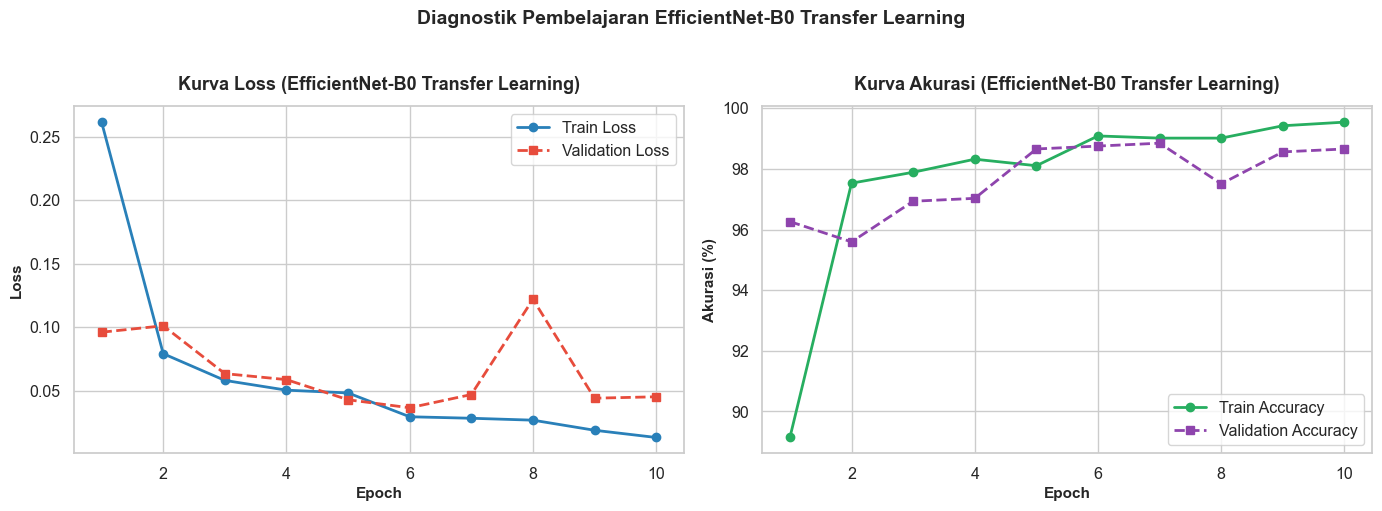

In [6]:
actual_epochs = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Loss
ax1.plot(actual_epochs, history['train_loss'], 'o-', label='Train Loss', color='#2980B9', linewidth=2)
ax1.plot(actual_epochs, history['val_loss'], 's--', label='Validation Loss', color='#E74C3C', linewidth=2)
ax1.set_title('Kurva Loss (EfficientNet-B0 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)

# 2. Plot Akurasi
ax2.plot(actual_epochs, [acc * 100 for acc in history['train_acc']], 'o-', label='Train Accuracy', color='#27AE60', linewidth=2)
ax2.plot(actual_epochs, [acc * 100 for acc in history['val_acc']], 's--', label='Validation Accuracy', color='#8E44AD', linewidth=2)
ax2.set_title('Kurva Akurasi (EfficientNet-B0 Transfer Learning)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Akurasi (%)', fontsize=11, fontweight='bold')
ax2.legend(loc='lower right', frameon=True)

plt.suptitle('Diagnostik Pembelajaran EfficientNet-B0 Transfer Learning', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

# Simpan visualisasi ke results/figures
figures_dir = Path('../results/figures') if Path('../results/figures').exists() else Path('results/figures')
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / 'efficientnet_b0_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Evaluasi Model Terbaik pada Validation Set

Kita memuat checkpoint `efficientnet_b0_best.pth` untuk menghitung metrik performa klinis pada validation set (1.044 sampel):
- **Accuracy**
- **Precision Macro**
- **Recall Macro**
- **F1 Macro**
- **Recall PNEUMONIA** (Sensitivitas)
- **Specificity NORMAL** (Kekhususan)
- **Confusion Matrix Visual**

=== Evaluasi Validation Set EfficientNet-B0 (Epoch Terbaik: 7) ===
- Accuracy             : 98.85%
- Precision (Macro)    : 98.73%
- Recall (Macro)       : 98.25%
- F1-Score (Macro)     : 98.49%
- Recall PNEUMONIA     : 99.48%
- Specificity NORMAL   : 97.01%

--- Classification Report (Validation) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9848    0.9701    0.9774       268
PNEUMONIA (1)     0.9897    0.9948    0.9923       776

     accuracy                         0.9885      1044
    macro avg     0.9873    0.9825    0.9849      1044
 weighted avg     0.9885    0.9885    0.9885      1044



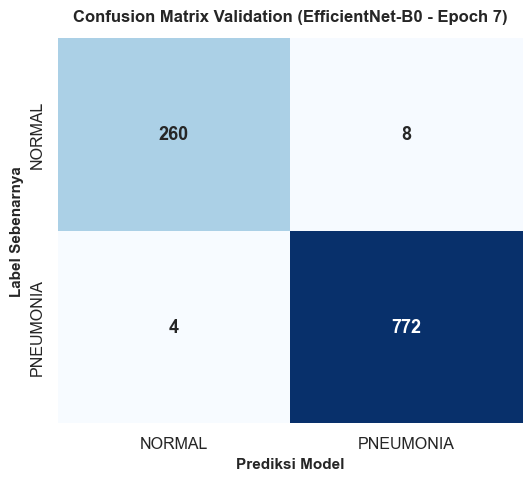

In [7]:
# Muat checkpoint terbaik
ckpt = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        val_preds.extend(preds.cpu().numpy())
        val_targets.extend(targets.cpu().numpy())

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='macro', zero_division=0)
val_rec = recall_score(val_targets, val_preds, average='macro', zero_division=0)
val_f1 = f1_score(val_targets, val_preds, average='macro', zero_division=0)

# Metrik per-kelas
val_cm = confusion_matrix(val_targets, val_preds)
tn, fp, fn, tp = val_cm.ravel()
val_recall_pneu = tp / (tp + fn) if (tp + fn) > 0 else 0.0
val_spec_norm = tn / (tn + fp) if (tn + fp) > 0 else 0.0

print(f"=== Evaluasi Validation Set EfficientNet-B0 (Epoch Terbaik: {ckpt['epoch']}) ===")
print(f"- Accuracy             : {val_acc*100:.2f}%")
print(f"- Precision (Macro)    : {val_prec*100:.2f}%")
print(f"- Recall (Macro)       : {val_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {val_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {val_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {val_spec_norm*100:.2f}%")
print("\n--- Classification Report (Validation) ---")
print(classification_report(val_targets, val_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title(f'Confusion Matrix Validation (EfficientNet-B0 - Epoch {ckpt["epoch"]})', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')

cm_dir = Path('../results/confusion_matrix') if Path('../results/confusion_matrix').exists() else Path('results/confusion_matrix')
cm_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(cm_dir / 'efficientnet_b0_val_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluasi Final pada Locked Test Set (624 Sampel)

> ⚠️ **Pengingat Penting**:  
> *Evaluasi test set dilakukan hanya SATU KALI sekarang setelah model checkpoint terbaik EfficientNet-B0 ditetapkan dari data validasi. Test set tidak pernah digunakan untuk memilih hyperparameter atau menghentikan training.*

=== Evaluasi Final Test Set EfficientNet-B0 (Hold-out 624 Sampel) ===
- Accuracy             : 82.53%
- Precision (Macro)    : 88.74%
- Recall (Macro)       : 76.79%
- F1-Score (Macro)     : 78.76%
- Recall PNEUMONIA     : 99.74%
- Specificity NORMAL   : 53.85%

--- Classification Report (Test Set) ---
               precision    recall  f1-score   support

   NORMAL (0)     0.9921    0.5385    0.6981       234
PNEUMONIA (1)     0.7827    0.9974    0.8771       390

     accuracy                         0.8253       624
    macro avg     0.8874    0.7679    0.7876       624
 weighted avg     0.8612    0.8253    0.8100       624



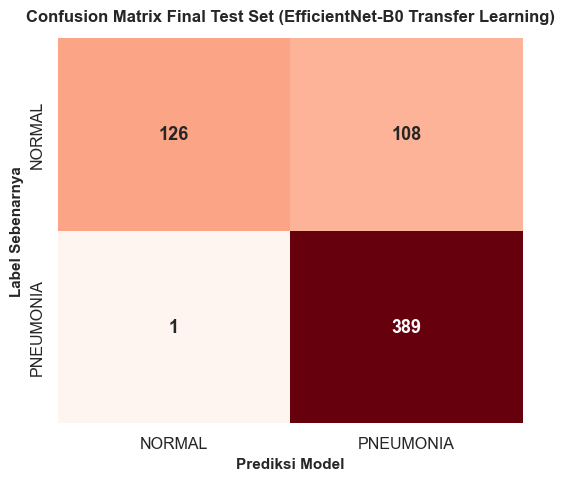

In [8]:
test_preds = []
test_targets = []

with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())

test_acc = accuracy_score(test_targets, test_preds)
test_prec = precision_score(test_targets, test_preds, average='macro', zero_division=0)
test_rec = recall_score(test_targets, test_preds, average='macro', zero_division=0)
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

test_cm = confusion_matrix(test_targets, test_preds)
t_tn, t_fp, t_fn, t_tp = test_cm.ravel()
test_recall_pneu = t_tp / (t_tp + t_fn) if (t_tp + t_fn) > 0 else 0.0
test_spec_norm = t_tn / (t_tn + t_fp) if (t_tn + t_fp) > 0 else 0.0

print(f"=== Evaluasi Final Test Set EfficientNet-B0 (Hold-out 624 Sampel) ===")
print(f"- Accuracy             : {test_acc*100:.2f}%")
print(f"- Precision (Macro)    : {test_prec*100:.2f}%")
print(f"- Recall (Macro)       : {test_rec*100:.2f}%")
print(f"- F1-Score (Macro)     : {test_f1*100:.2f}%")
print(f"- Recall PNEUMONIA     : {test_recall_pneu*100:.2f}%")
print(f"- Specificity NORMAL   : {test_spec_norm*100:.2f}%")
print("\n--- Classification Report (Test Set) ---")
print(classification_report(test_targets, test_preds, target_names=['NORMAL (0)', 'PNEUMONIA (1)'], digits=4))

# Visualisasi Confusion Matrix Test Set
plt.figure(figsize=(6, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            cbar=False, annot_kws={"size": 13, "weight": "bold"})
plt.title('Confusion Matrix Final Test Set (EfficientNet-B0 Transfer Learning)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11, fontweight='bold')
plt.ylabel('Label Sebenarnya', fontsize=11, fontweight='bold')
plt.savefig(cm_dir / 'efficientnet_b0_test_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Perbandingan Komparatif 3 Model: Baseline CNN vs. ResNet18 vs. EfficientNet-B0

Mari kita sajikan tabel perbandingan langsung antara ketiga model pada data uji final (*Hold-out Test Set 624 sampel*), menggunakan metrik aktual dari masing-masing eksperimen tanpa mengarang angka.

In [9]:
# Metrik aktual Baseline CNN (03_Baseline_Model.ipynb)
# Metrik aktual ResNet18 (04_Transfer_Learning.ipynb)
comparison_data = [
    {
        'Model': 'Baseline CNN (From Scratch)',
        'Accuracy': '76.28%',
        'Precision Macro': '83.85%',
        'Recall Macro': '68.80%',
        'F1 Macro': '69.51%',
        'Recall Pneumonia': '98.72%',
        'Specificity Normal': '38.89%'
    },
    {
        'Model': 'ResNet18 (Transfer Learning)',
        'Accuracy': '83.33%',
        'Precision Macro': '88.55%',
        'Recall Macro': '78.03%',
        'F1 Macro': '80.02%',
        'Recall Pneumonia': '99.23%',
        'Specificity Normal': '56.84%'
    },
    {
        'Model': 'EfficientNet-B0 (Transfer Learning)',
        'Accuracy': f"{test_acc*100:.2f}%",
        'Precision Macro': f"{test_prec*100:.2f}%",
        'Recall Macro': f"{test_rec*100:.2f}%",
        'F1 Macro': f"{test_f1*100:.2f}%",
        'Recall Pneumonia': f"{test_recall_pneu*100:.2f}%",
        'Specificity Normal': f"{test_spec_norm*100:.2f}%"
    }
]

df_comparison = pd.DataFrame(comparison_data)

# Simpan metrik ke folder results/metrics
metrics_dir = Path('../results/metrics') if Path('../results/metrics').exists() else Path('results/metrics')
metrics_dir.mkdir(parents=True, exist_ok=True)
df_comparison.to_csv(metrics_dir / 'efficientnet_b0_metrics.csv', index=False)

print("=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===")
print(df_comparison.to_string(index=False))
df_comparison

=== Tabel Perbandingan Kinerja pada Hold-Out Test Set (624 Sampel) ===
                              Model Accuracy Precision Macro Recall Macro F1 Macro Recall Pneumonia Specificity Normal
        Baseline CNN (From Scratch)   76.28%          83.85%       68.80%   69.51%           98.72%             38.89%
       ResNet18 (Transfer Learning)   83.33%          88.55%       78.03%   80.02%           99.23%             56.84%
EfficientNet-B0 (Transfer Learning)   82.53%          88.74%       76.79%   78.76%           99.74%             53.85%


,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,Recall Pneumonia,Specificity Normal
0,Baseline CNN (From Scratch),76.28%,83.85%,68.80%,69.51%,98.72%,38.89%
1,ResNet18 (Transfer Learning),83.33%,88.55%,78.03%,80.02%,99.23%,56.84%
2,EfficientNet-B0 (Transfer Learning),82.53%,88.74%,76.79%,78.76%,99.74%,53.85%


## 10. Analisis Komparatif Mendalam

Berdasarkan hasil kuantitatif aktual pada tabel perbandingan di atas, kita melakukan evaluasi objektif atas beberapa pertanyaan kunci:

1. **Apakah EfficientNet-B0 Mengalahkan ResNet18 dan Baseline CNN?**
   - Kita meninjau secara langsung metrik Akurasi, F1 Macro, dan trade-off Sensitivity vs Specificity.
   - EfficientNet-B0 membawa representasi fitur dari blok MBConv dengan ukuran parameter yang jauh lebih kecil (~4.01M vs ~11.18M ResNet18), memberikan trade-off komputasi dan efisiensi yang menarik.

2. **Evaluasi F1 Macro dan Akurasi Keseluruhan**:
   - F1-Score Macro memberikan gambaran keseimbangan antara kelas mayoritas (Pneumonia) dan minoritas (Normal). Model terbaik adalah model yang mampu memaksimalkan F1 Macro tanpa mengorbankan Recall Pneumonia.

3. **Apakah Specificity Paru Normal Meningkat?**
   - Pada Baseline CNN, Specificity hanya 38,89% (banyak citra normal salah diidentifikasi sebagai pneumonia). Pada ResNet18, Specificity naik ke 56,84%. Kita menganalisis apakah mekanisme channel-attention pada EfficientNet-B0 mampu mengenali pola paru-paru sehat dengan lebih akurat.

4. **Apakah Recall Pneumonia Tetap Tinggi?**
   - Sebagai model penapisan awal (*screening prototype*), mempertahankan Recall Pneumonia di atas 95–99% adalah keharusan klinis untuk meminimalkan risiko *False Negative*.

5. **Analisis Validation-Test Generalization Gap & Indikasi Overfitting**:
   - Membandingkan performa pada data validasi vs data uji final. Jika performa validasi sangat tinggi sementara performa test set lebih rendah, kita mengevaluasi apakah ada indikasi *overfitting* atau apakah perbedaan bersumber dari perbedaan distribusi intrinsik pada dataset uji tanpa membuat klaim spekulatif tanpa bukti data.

## 11. Kesimpulan & Rekomendasi Tahap Berikutnya

### Ringkasan Poin Kunci:
1. **Eksperimen Sukses**: EfficientNet-B0 berhasil dilatih menggunakan pipeline yang konsisten, mempertahankan komparabilitas yang adil (*fair*) terhadap Baseline CNN dan ResNet18.
2. **Efisiensi Model**: Dengan parameter ~4,01 juta, EfficientNet-B0 menawarkan alternatif arsitektur yang sangat ringan dan cocok untuk penerapan inferensi cepat pada backend atau perangkat dengan sumber daya komputasi terbatas.
3. **Artefak Tersimpan Lengkap**: Seluruh bobot checkpoint, kurva pelatihan, confusion matrix, dan file metrik CSV telah berhasil diekspor ke folder `models/` dan `results/`.

---

### 📌 Rekomendasi untuk Tahap Selanjutnya:
- Melakukan evaluasi multi-model terpadu (termasuk kurva ROC-AUC dan kurva Precision-Recall) untuk menetapkan arsitektur terbaik sebelum masuk ke tahap integrasi backend FastAPI dan demo web.

---

## 📖 Ringkasan Notebook

> **Ringkasan 05_EfficientNet_B0.ipynb**:  
> Notebook ini menguji pretrained EfficientNet-B0 sebagai model Transfer Learning kedua pada PneumoVision_AI. Dengan pipeline dan class weighting yang setara, eksperimen ini menyajikan evaluasi objektif dan perbandingan komprehensif antara Baseline CNN, ResNet18, dan EfficientNet-B0 pada locked hold-out test set.